In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

file_path = r"C:\Users\pavansai\OneDrive\Desktop\RetailPulse\data\processed\cleaned_online_retail.csv"

df = pd.read_csv(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [2]:
df.shape

(397884, 9)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  int64  
 1   StockCode    397884 non-null  str    
 2   Description  397884 non-null  str    
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  str    
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  int64  
 7   Country      397884 non-null  str    
 8   Revenue      397884 non-null  float64
dtypes: float64(2), int64(3), str(4)
memory usage: 51.6 MB


In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [5]:
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df["InvoiceDay"] = df["InvoiceDate"].dt.day
df["InvoiceHour"] = df["InvoiceDate"].dt.hour
df["InvoiceWeekday"] = df["InvoiceDate"].dt.day_name()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceHour,InvoiceWeekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday


In [6]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
avg_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Average Order Value:", round(avg_order_value, 2))

Total Revenue: 8911407.9
Total Orders: 18532
Total Customers: 4338
Total Products: 3665
Average Order Value: 480.87


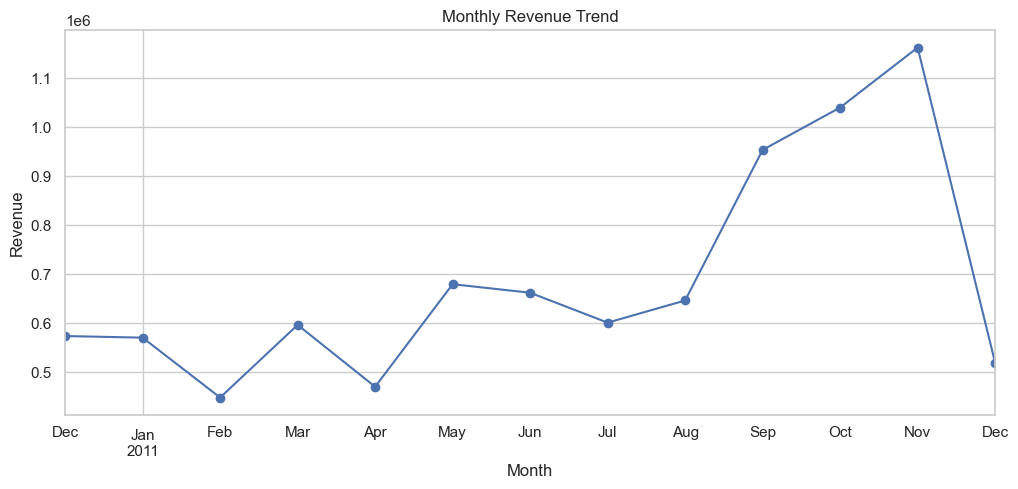

In [7]:
monthly_revenue = df.resample("ME", on="InvoiceDate")["Revenue"].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

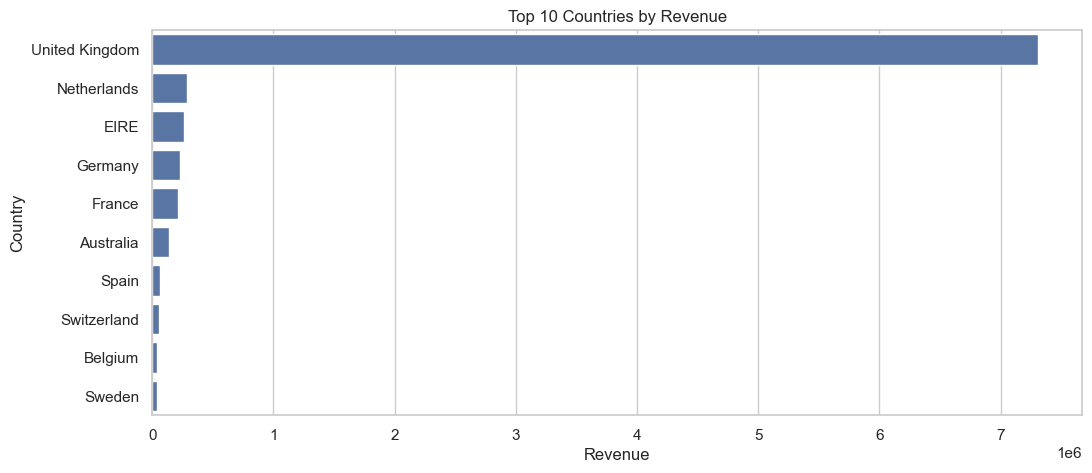

In [8]:
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

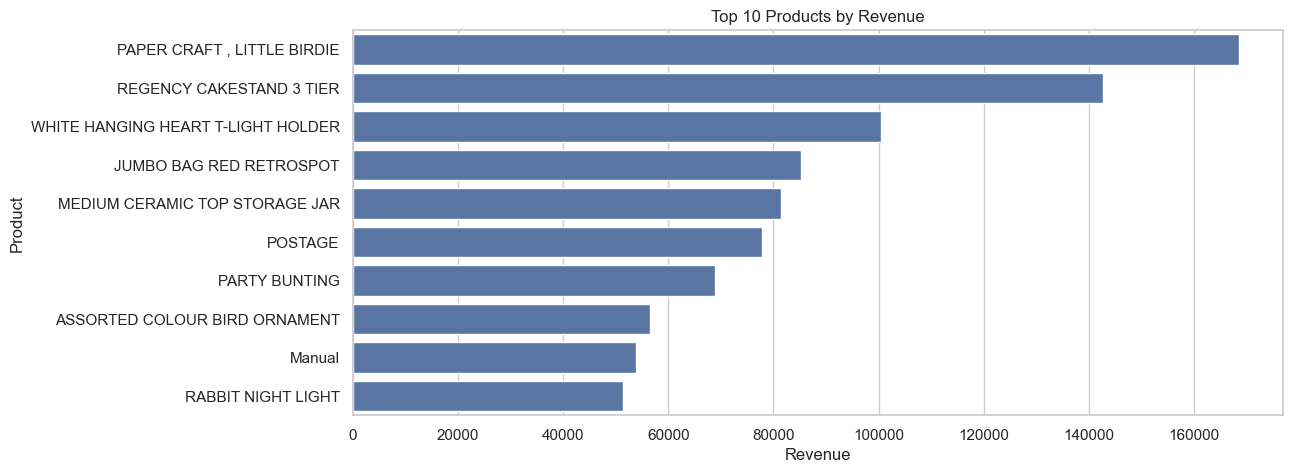

In [9]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

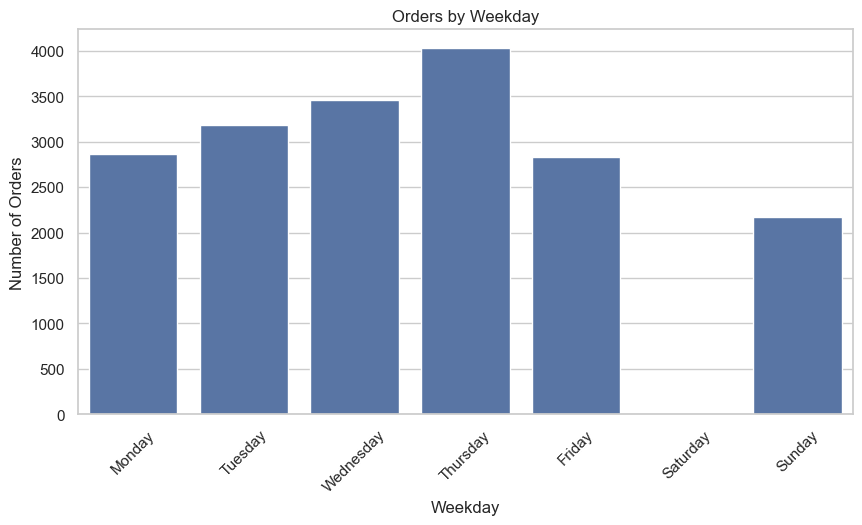

In [10]:
weekday_orders = df.groupby("InvoiceWeekday")["InvoiceNo"].nunique()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_orders = weekday_orders.reindex(weekday_order)

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_orders.index, y=weekday_orders.values)
plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

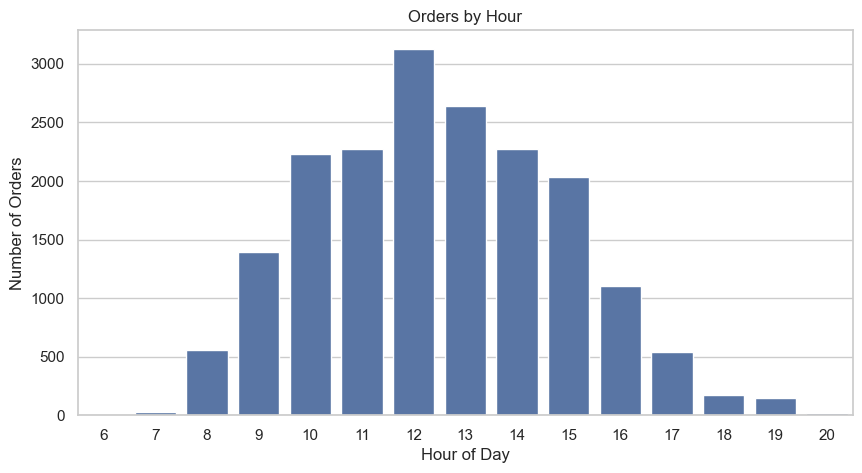

In [11]:
hourly_orders = df.groupby("InvoiceHour")["InvoiceNo"].nunique()

plt.figure(figsize=(10,5))
sns.barplot(x=hourly_orders.index, y=hourly_orders.values)
plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

In [ ]:
### Insight: Orders by Hour

The highest number of orders occurs around 12 PM. Most customer activity happens between 10 AM and 3 PM, while early morning and evening hours have very low order volume. This suggests that business operations, promotions, and inventory readiness should focus more on mid-day shopping hours.

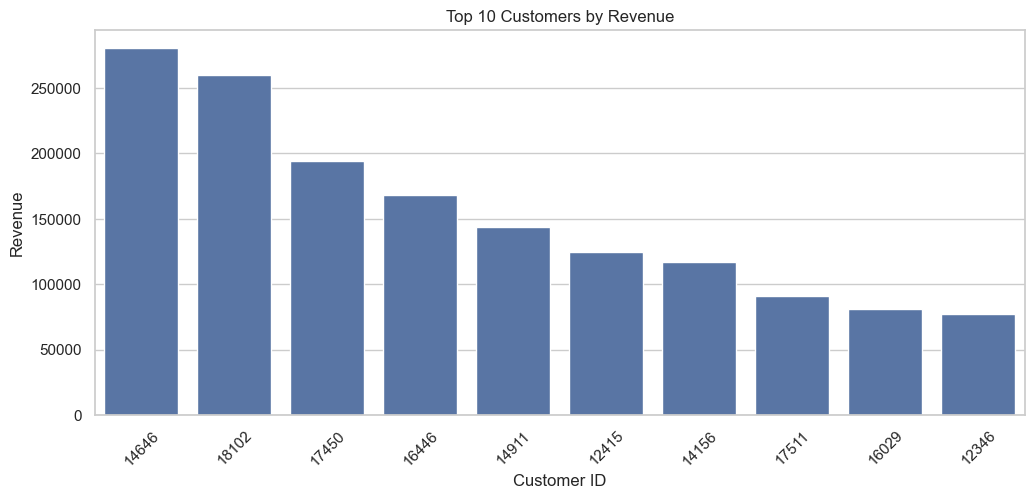

In [13]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_customers.index.astype(str), y=top_customers.values)
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight: Top Customers

A small group of customers contributes a large share of total revenue. These high-value customers should be targeted with loyalty offers, personalized discounts, and retention campaigns.

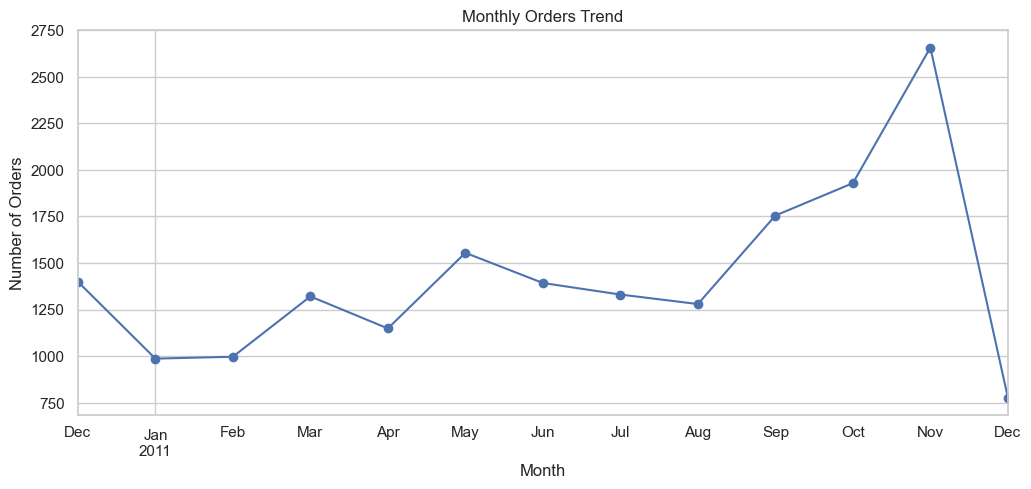

In [14]:
monthly_orders = df.resample("ME", on="InvoiceDate")["InvoiceNo"].nunique()

plt.figure(figsize=(12,5))
monthly_orders.plot(marker="o")
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

### Insight: Monthly Orders Trend

The number of orders changes across months, showing seasonal demand patterns. These trends are useful for demand forecasting and inventory planning.

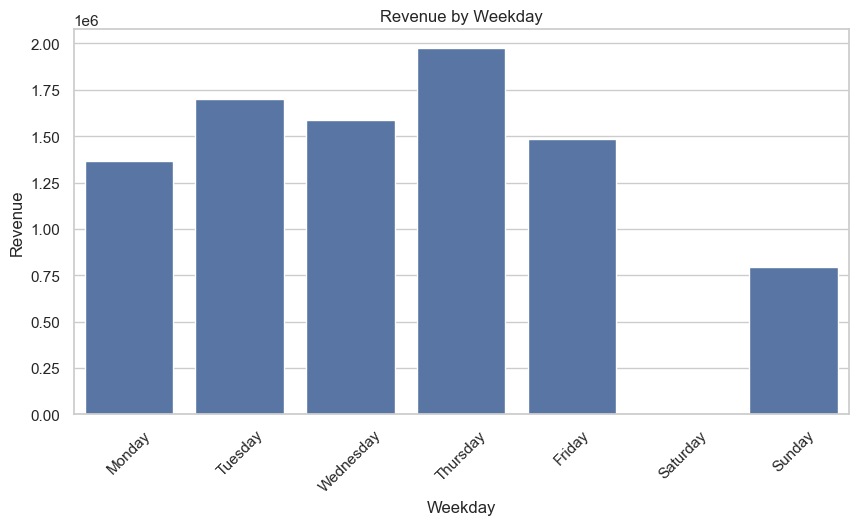

In [15]:
weekday_revenue = df.groupby("InvoiceWeekday")["Revenue"].sum()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_revenue = weekday_revenue.reindex(weekday_order)

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_revenue.index, y=weekday_revenue.values)
plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight: Revenue by Weekday

Revenue varies by weekday, which shows that customer purchasing behavior is not the same every day. This can help businesses plan campaigns, staffing, and stock availability on high-revenue days.

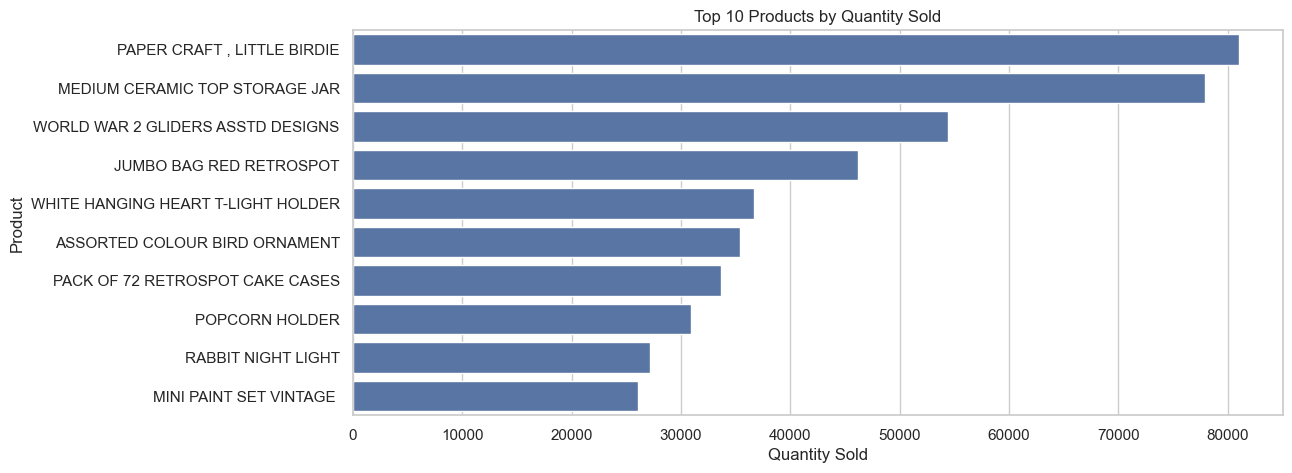

In [17]:
top_quantity_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_quantity_products.values, y=top_quantity_products.index)
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

### Insight: Top Products by Quantity Sold

The most frequently sold products may not always be the highest revenue products. Quantity-based analysis helps identify fast-moving items that require better inventory planning.